<a href="https://colab.research.google.com/github/sasurasa/2025/blob/main/SI_BA_Dec25.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [33]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import io
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [26]:
df = pd.read_csv('/content/Bilirubin.csv')

In [14]:
df.head()

,serial,pretb,predb,preggt,tbimm,dbimm,ggtimm,tb7d,dbi7d,ggt7d,...,tb6m,db6m,ggt6m,tb2y,db2y,ggt2y,tb5y,db5y,ggt5y,Unnamed: 28
0,1,7.1,5.0,450.00,9.4,7.5,144.00,6.5,4.8,136.00,...,,,,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,13.3,9.8,114.00,15.0,10.8,71.00,17.8,12.8,89.00,...,,,,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,9.6,7.3,524.00,7.6,6.0,286.00,3.7,2.8,477.00,...,2.60,2.20,1391.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,11.8,7.8,1222.00,7.0,4.8,661.00,9.8,7.5,1220.00,...,10.90,7.30,380.00,10.9,9.3,262.0,5.3,4.24,422.0,NaN
4,5,10.5,8.1,638.00,10.0,7.5,327.00,4.4,3.4,586.00,...,1.50,0.80,268.00,0.9,0.3,NaN,0.7,0.42,NaN,NaN


In [27]:
df_melted = df.melt(id_vars=['serial'], var_name='variable', value_name='level')

In [16]:
df_melted.head()

,serial,variable,level
0,1,pretb,7.1
1,2,pretb,13.3
2,3,pretb,9.6
3,4,pretb,11.8
4,5,pretb,10.5


In [28]:
def clean_type(row):
    val = row['variable']
    if 'ggt' in val: return 'GGT'
    if 'db' in val: return 'Direct Bilirubin'
    return 'Total Bilirubin'

df_melted['biomarker'] = df_melted.apply(clean_type, axis=1)

In [29]:
time_mapping = {
    'pretb': 0, 'predb': 0, 'preggt': 0,
    'tbimm': 1, 'dbimm': 1, 'ggtimm': 1,
    'tb7d': 7, 'dbi7d': 7, 'ggt7d': 7,
    'tb3m': 90, 'db3m': 90, 'ggt3m': 90,
    'tb4m': 120, 'db4m': 120, 'ggt4m': 120,
    'tb5m': 150, 'db5m': 150, 'ggt5m': 150,
    'tb6m': 180, 'db6m': 180, 'ggt6m': 180,
    'tb2y': 730, 'db2y': 730, 'ggt2y': 730,
    'tb5y': 1825, 'db5y': 1825, 'ggt5y': 1825
}

df_melted['days'] = df_melted['variable'].map(time_mapping)

In [39]:
df_melted['level'] = pd.to_numeric(df_melted['level'], errors='coerce')
df_clean = df_melted.dropna(subset=['level', 'days'])

In [31]:
df_clean

,serial,variable,level,biomarker,days
0,1,pretb,7.1,Total Bilirubin,0.0
1,2,pretb,13.3,Total Bilirubin,0.0
2,3,pretb,9.6,Total Bilirubin,0.0
3,4,pretb,11.8,Total Bilirubin,0.0
4,5,pretb,10.5,Total Bilirubin,0.0
...,...,...,...,...,...
2812,83,ggt5y,176.0,GGT,1825.0
2813,84,ggt5y,14.0,GGT,1825.0
2814,85,ggt5y,247.0,GGT,1825.0
2815,86,ggt5y,714.0,GGT,1825.0


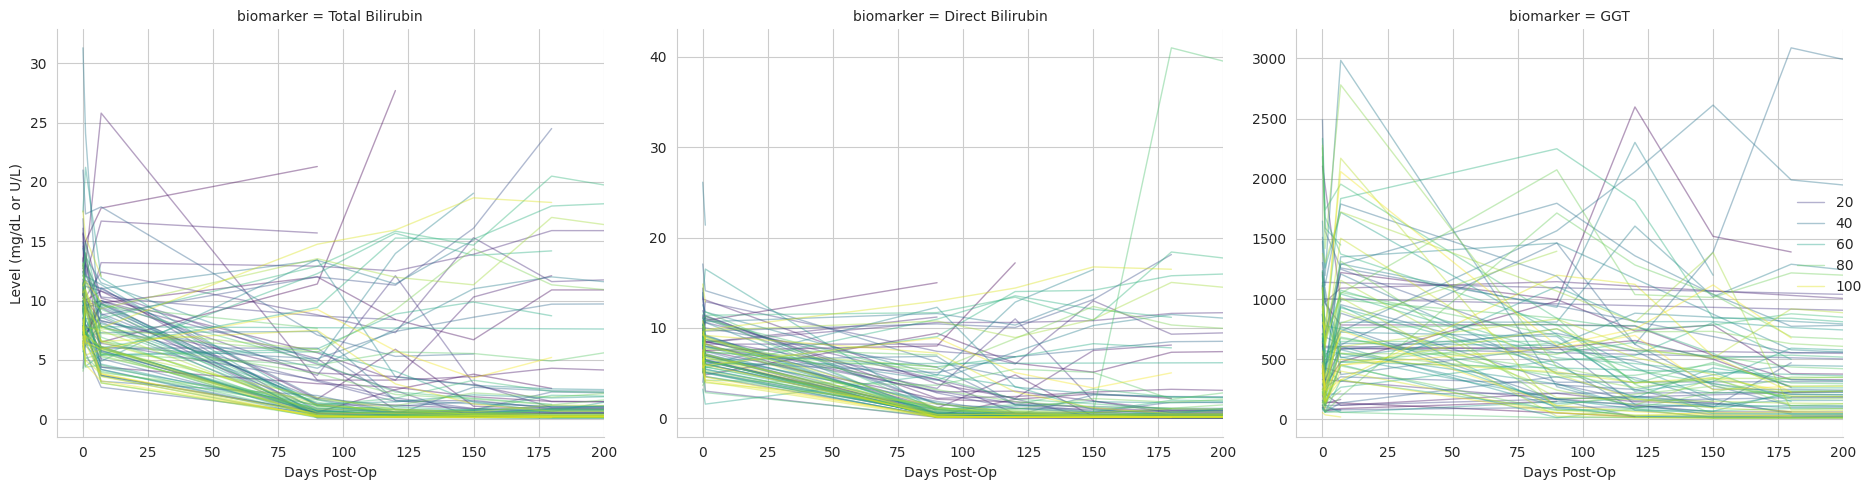

In [32]:
sns.set_style("whitegrid")
g = sns.FacetGrid(df_clean, col="biomarker", sharey=False, height=5, aspect=1.2)
g.map_dataframe(sns.lineplot, x="days", y="level", hue="serial",
                units="serial", estimator=None, alpha=0.4, linewidth=1, palette="viridis")
g.set_axis_labels("Days Post-Op", "Level (mg/dL or U/L)")
g.add_legend()
plt.xlim(-10, 200)
plt.tight_layout()
plt.show()

In [35]:
target_cols = ['predb', 'dbimm', 'db7d', 'db3m', 'db4m', 'db5m', 'db6m']

In [40]:
X = df[['serial'] + target_cols].copy()

In [41]:
X.set_index('serial', inplace=True)

In [44]:
for col in target_cols:
    X[col] = pd.to_numeric(X[col], errors='coerce')
X_imputed = X.interpolate(method='linear', axis=1, limit_direction='both')
X_imputed = X_imputed.dropna()

In [45]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

In [46]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

In [47]:
X_imputed['Cluster'] = clusters

In [48]:
X_reset = X_imputed.reset_index()
X_long = X_reset.melt(id_vars=['serial', 'Cluster'], var_name='timepoint', value_name='level')

In [49]:
time_map = {'predb':0, 'dbimm':1, 'dbi7d':7, 'db3m':90, 'db4m':120, 'db5m':150, 'db6m':180}
X_long['days'] = X_long['timepoint'].map(time_map)

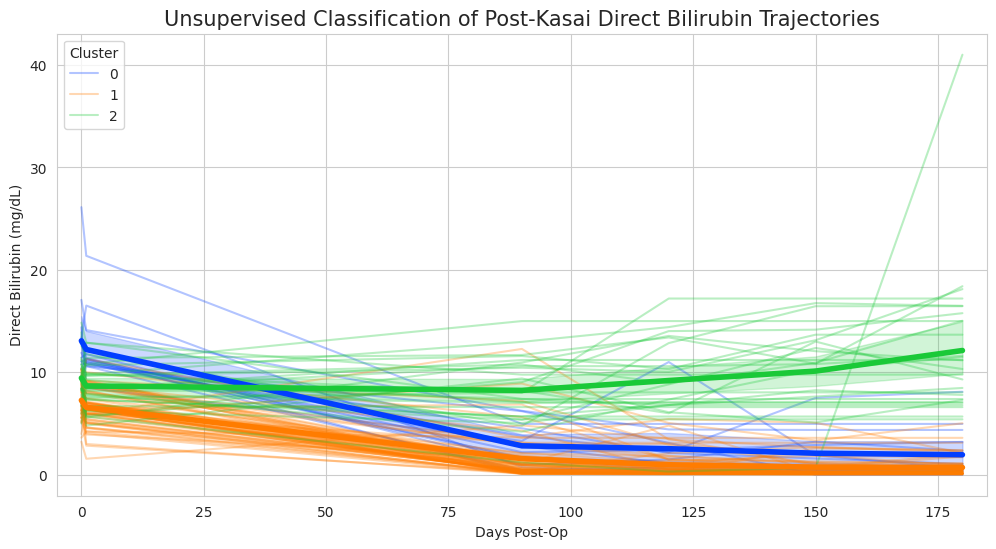

In [50]:
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")
sns.lineplot(data=X_long, x='days', y='level', hue='Cluster', units='serial', estimator=None, alpha=0.3, palette='bright')
sns.lineplot(data=X_long, x='days', y='level', hue='Cluster', linewidth=4, palette='bright', legend=False)

plt.title('Unsupervised Classification of Post-Kasai Direct Bilirubin Trajectories', fontsize=15)
plt.xlabel('Days Post-Op')
plt.ylabel('Direct Bilirubin (mg/dL)')
plt.xlim(-5, 185) # Focus on first 6 months
plt.show()


In [51]:
print("Patient Counts per Cluster:")
print(X_imputed['Cluster'].value_counts())

Patient Counts per Cluster:
Cluster
1    63
2    28
0    14
Name: count, dtype: int64


In [52]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import io
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline
from sklearn.metrics import roc_auc_score, confusion_matrix, accuracy_score


In [53]:
df = pd.read_csv('/content/Bilirubin_label.csv')

In [54]:
features_7d = ['pretb','predb','preggt', 'tbimm','dbimm','ggtimm', 'tb7d','db7d','ggt7d']
features_3m = features_7d + ['tb3m','db3m','ggt3m']
features_6m = features_3m + ['tb4m','db4m','ggt4m', 'tb5m','db5m','ggt5m', 'tb6m','db6m','ggt6m']

model_names = ['7 Days Data', '3 Months Data', '6 Months Data']
feature_sets = [features_7d, features_3m, features_6m]

In [55]:
y = df['twoynlstatus']

In [63]:
results = []

for name, feats in zip(model_names, feature_sets):
    # Prepare X
    X = df[feats].copy()

    # Convert columns to numeric, coercing errors to NaN
    for col in feats:
        X[col] = pd.to_numeric(X[col], errors='coerce')

    # Impute missing values (using mean imputation for simplicity)
    # In a real clinical paper, you might use more advanced imputation like KNN
    imputer = SimpleImputer(strategy='mean')
    X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

    # Initialize Random Forest (good for non-linear clinical data)
    rf_model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=5)

    # Cross Validation (5-fold) to avoid overfitting on small data
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(rf_model, X_imputed, y, cv=cv, scoring='accuracy')
    auc_scores = cross_val_score(rf_model, X_imputed, y, cv=cv, scoring='roc_auc')

    results.append({
        'Window': name,
        'Accuracy': scores.mean(),
        'AUC': auc_scores.mean()
    })

    # Optional: Feature Importance for the 3-month model (most clinically relevant)
    if name == '3 Months Data':
        rf_model.fit(X_imputed, y)
        importances = pd.DataFrame({
            'feature': feats,
            'importance': rf_model.feature_importances_
        }).sort_values('importance', ascending=False)
        top_features = importances

In [64]:
print("--- PREDICTION ACCURACY BY TIME WINDOW ---")
results_df = pd.DataFrame(results)
print(results_df)
print("\n--- TOP PREDICTORS (from 3-month model) ---")
print(top_features.head(10))

--- PREDICTION ACCURACY BY TIME WINDOW ---
          Window  Accuracy       AUC
0    7 Days Data  0.742857  0.696111
1  3 Months Data  0.838095  0.853056
2  6 Months Data  0.828571  0.867222

--- TOP PREDICTORS (from 3-month model) ---
   feature  importance
10    db3m    0.189206
9     tb3m    0.173874
1    predb    0.086062
3    tbimm    0.085855
4    dbimm    0.069118
0    pretb    0.068095
11   ggt3m    0.067336
8    ggt7d    0.062004
2   preggt    0.059541
5   ggtimm    0.048049


/tmp/ipython-input-569566895.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_features.head(10), x='importance', y='feature', palette='viridis')


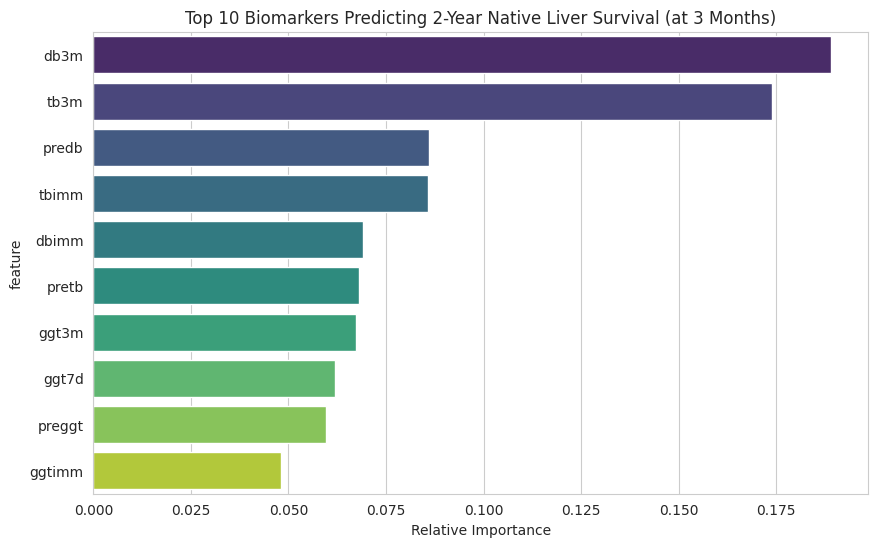

In [65]:
plt.figure(figsize=(10, 6))
sns.barplot(data=top_features.head(10), x='importance', y='feature', palette='viridis')
plt.title('Top 10 Biomarkers Predicting 2-Year Native Liver Survival (at 3 Months)')
plt.xlabel('Relative Importance')
plt.show()

In [66]:
top_3_feats = top_features['feature'].head(3).tolist()
plot_data = df[top_3_feats + ['twoynlstatus']].copy()

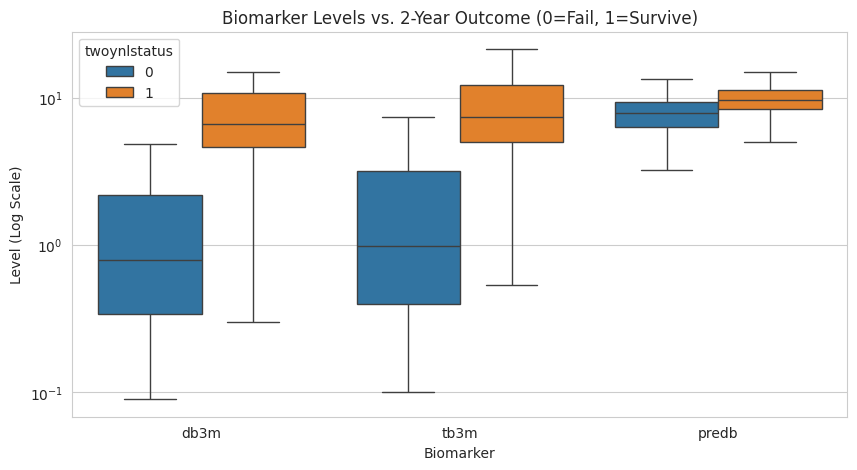

In [68]:
plot_data_long = plot_data.melt(id_vars='twoynlstatus', var_name='Biomarker', value_name='Level')
plot_data_long['Level'] = pd.to_numeric(plot_data_long['Level'], errors='coerce')
plot_data_long.dropna(subset=['Level'], inplace=True)

plt.figure(figsize=(10, 5))
sns.boxplot(data=plot_data_long, x='Biomarker', y='Level', hue='twoynlstatus', showfliers=False)
plt.title('Biomarker Levels vs. 2-Year Outcome (0=Fail, 1=Survive)')
plt.yscale('log') # Log scale because GGT can be massive
plt.ylabel('Level (Log Scale)')
plt.show()